<a href="https://colab.research.google.com/github/24Sinchana/project/blob/main/ML%20PROJECTS/FaceMask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:08<00:00, 23.7MB/s]
100% 163M/163M [00:08<00:00, 20.8MB/s]


In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask') #creates list containing files in with mask folder
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2021.jpg', 'with_mask_3111.jpg', 'with_mask_1236.jpg', 'with_mask_3088.jpg', 'with_mask_1657.jpg']
['with_mask_689.jpg', 'with_mask_2017.jpg', 'with_mask_3505.jpg', 'with_mask_356.jpg', 'with_mask_2520.jpg']


In [8]:
without_mask_files = os.listdir('/content/data/without_mask') #creates list containing files in with mask folder
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_151.jpg', 'without_mask_1129.jpg', 'without_mask_2143.jpg', 'without_mask_585.jpg', 'without_mask_1170.jpg']
['without_mask_2523.jpg', 'without_mask_1941.jpg', 'without_mask_55.jpg', 'without_mask_2805.jpg', 'without_mask_3247.jpg']


In [9]:
#check number of with mask images and withou mask images
print('Number of mask images:',len(with_mask_files))
print('Number of without mask images:',len(without_mask_files))

Number of mask images: 3725
Number of without mask images: 3828


In [10]:
#create labels for the images

with_mask_labels =[1]*3725

without_mask_labels=[0]*3828
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])
print(len(with_mask_labels))
print(len(without_mask_labels))

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]
3725
3828


In [11]:
#combining the lists
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


#displaying the images

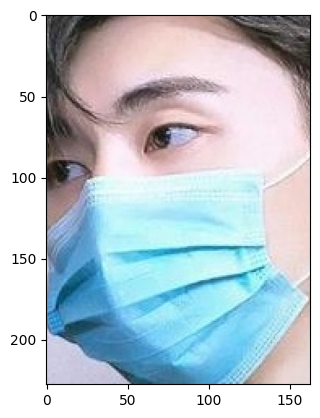

In [12]:
#displaying  with the mask images

img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

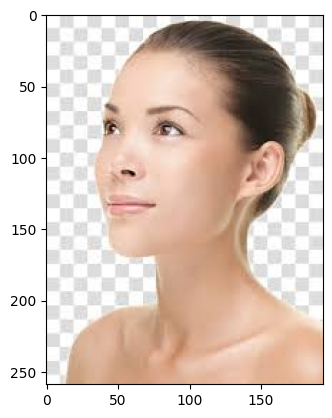

In [13]:
#displaying  without the mask images

img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

In [14]:
#resize images and then converyt numpy arrays

with_mask_path = '/content/data/with_mask/'
data = []

for file in with_mask_files:
  image = Image.open(with_mask_path + file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  img=np.array(image) #
  data.append(image) # all the images converted to numpy array will be stored in data


without_mask_path = '/content/data/without_mask/'

for file in without_mask_files:
  image = Image.open(without_mask_path + file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  img=np.array(image) #
  data.append(image) # all the images converted to numpy array will be stored in data



/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [15]:
type(data)

list

In [16]:
len(data)

7553

array([[[110,  92,  92],
        [113,  91,  93],
        [116,  90,  94],
        ...,
        [235, 254, 225],
        [237, 254, 226],
        [238, 254, 227]],

       [[117,  97,  98],
        [118,  96,  99],
        [121,  94,  99],
        ...,
        [237, 253, 225],
        [237, 253, 225],
        [238, 252, 226]],

       [[124, 103, 103],
        [124, 100, 102],
        [125,  97, 101],
        ...,
        [238, 253, 225],
        [238, 252, 225],
        [238, 250, 225]],

       ...,

       [[ 43,  33,  49],
        [ 41,  31,  48],
        [ 40,  30,  47],
        ...,
        [200, 174, 139],
        [197, 175, 132],
        [194, 175, 127]],

       [[ 44,  32,  50],
        [ 42,  31,  48],
        [ 42,  30,  47],
        ...,
        [198, 174, 130],
        [197, 174, 129],
        [196, 175, 128]],

       [[ 49,  36,  54],
        [ 48,  34,  52],
        [ 48,  34,  51],
        ...,
        [195, 171, 122],
        [197, 175, 126],
        [198, 176, 129]]], dtype=uint8)
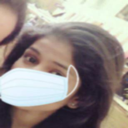

In [17]:
data[0] #pixel values of first image

In [18]:
type(data[0])

numpy.ndarray

In [19]:
data[0].shape

(128, 128, 3)

In [20]:
#convert image list and label list to numpy array

X=np.array(data)
Y=np.array(labels)
print(type(X))
print(type(Y))
print(X.shape)
print(Y.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(7553, 128, 128, 3)
(7553,)


In [21]:
print(Y)

[1 1 1 ... 0 0 0]


In [22]:
#splitting data into training data and test data
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state=2)
print(X.shape,X_train.shape,X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [23]:
#scaling the data
#0 represents black, and 255 represents white

X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [24]:
print(X_train_scaled[0])

[[[0.89411765 0.9254902  0.9372549 ]
  [0.89019608 0.92156863 0.92941176]
  [0.8745098  0.90588235 0.91764706]
  ...
  [0.93333333 0.94117647 0.9372549 ]
  [0.94117647 0.94901961 0.94509804]
  [0.94117647 0.94901961 0.94509804]]

 [[0.89411765 0.9254902  0.9372549 ]
  [0.89019608 0.92156863 0.92941176]
  [0.8745098  0.90588235 0.91764706]
  ...
  [0.92156863 0.92941176 0.9254902 ]
  [0.9254902  0.93333333 0.92941176]
  [0.9254902  0.93333333 0.92941176]]

 [[0.89411765 0.9254902  0.9372549 ]
  [0.89019608 0.92156863 0.93333333]
  [0.88235294 0.91372549 0.9254902 ]
  ...
  [0.90588235 0.91372549 0.90980392]
  [0.90196078 0.90980392 0.90588235]
  [0.90196078 0.90980392 0.90588235]]

 ...

 [[0.17647059 0.11372549 0.13333333]
  [0.16470588 0.11372549 0.13333333]
  [0.14901961 0.10196078 0.11764706]
  ...
  [0.18823529 0.1372549  0.16470588]
  [0.1372549  0.09019608 0.11764706]
  [0.11372549 0.06666667 0.09411765]]

 [[0.16078431 0.10196078 0.12156863]
  [0.15686275 0.10196078 0.12156863]


In [25]:
#building neural network (CNN)
import tensorflow as tf
from tensorflow import keras

In [27]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten()) # convert to 1D array

model.add(keras.layers.Dense(128, activation='relu')) # (2^n 128 neurons)
model.add(keras.layers.Dropout(0.5)) #dropout layer to ensure there is no overfitting(turnoff layers)

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid')) #output layer

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
#compile neural network
model.compile(optimizer ='adam',
              loss='sparse_categorical_crossentropy',
              metrics =['acc'])

In [30]:
#training the neural network
history = model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - acc: 0.6638 - loss: 0.7953 - val_acc: 0.8727 - val_loss: 0.2932
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.8782 - loss: 0.3017 - val_acc: 0.8826 - val_loss: 0.3102
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.8979 - loss: 0.2652 - val_acc: 0.8942 - val_loss: 0.2701
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.9050 - loss: 0.2469 - val_acc: 0.9058 - val_loss: 0.2505
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.9292 - loss: 0.1942 - val_acc: 0.9273 - val_loss: 0.2161


In [31]:
#model evaluaton on test data
loss,accuracy = model.evaluate(X_test_scaled,Y_test)
print('Test Accuracy =',accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9169 - loss: 0.2096
Test Accuracy = 0.9245532751083374


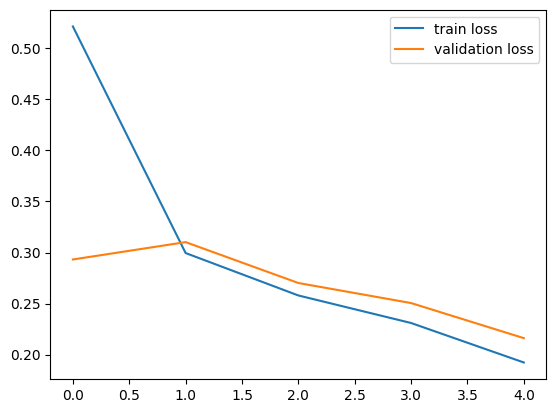

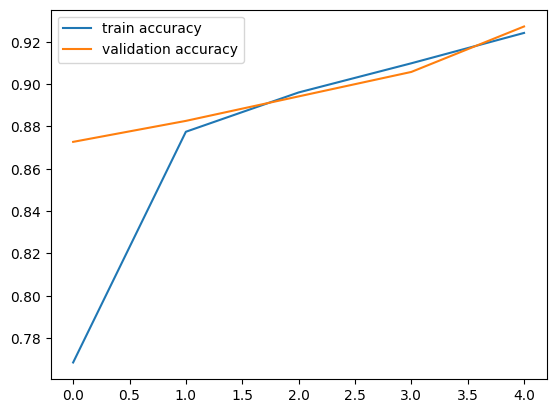

In [33]:
# plot the loss value
h=history
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

#loss is the difference between true value and tested value

Path of the image to be predicted: /content/download (1).jpg


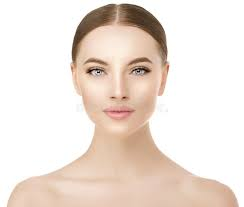

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[0.39448565 0.550508  ]]
1
The person in the image is wearing a mask


In [38]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/download 22.png


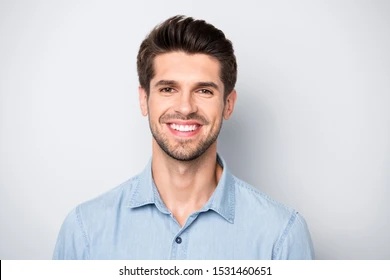

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.50206053 0.44263303]]
0
The person in the image is not wearing a mask


In [42]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')